# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

843
0.361199
63.868031


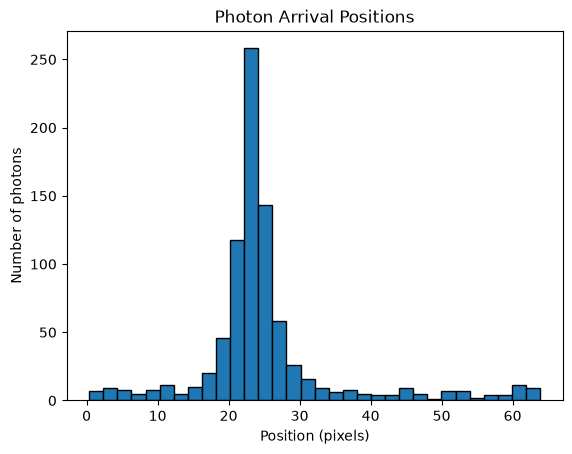

In [37]:
# Part 1: your work here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data/nraja3.csv")
x = data["x"].values

r0 = 4
beta = 2.5
xmin = 0
xmax = 64

a = 0.1875
back = 1 / 64

print(len(x))
print(np.min(x))
print(np.max(x))

plt.hist(x, bins=32, edgecolor="black")
plt.xlabel("Position (pixels)")
plt.ylabel("Number of photons")
plt.title("Photon Arrival Positions")
plt.show()

In [38]:
mean = np.mean(x)
std = np.std(x)
meanerr = std / np.sqrt(len(x))

print("Mean =", mean)
print("Uncertainty =", meanerr)
print("x0 =", mean, "+/-", meanerr, "pixels")

Mean = 25.199322113879003
Uncertainty = 0.34590104448922376
x0 = 25.199322113879003 +/- 0.34590104448922376 pixels


**ANSWER (a few sentences):**

*The estimator is biased. It is biased because of some of the photons coming from the background and most photons are concentrated around 23 and 24 pixels. Since the photons are spread across a 0-64 pixel detector and the center is at 32 pixels, the background pulls the sample mean to the right. The size of bias depends on how far the star is from the center of the detector and the bacground fraction.*

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [40]:
# Part 2: your work here

# Median
median = np.median(x)
print("Median:", median_x)

medvals = []

for i in range(1000):
    sample = np.random.choice(x, len(x), replace=True)
    medvals.append(np.median(sample))

mederr = np.std(medvals)

print("Median =", median, "+/-", mederr)

Median: 23.592328
Median = 23.592328 +/- 0.09452431656486181


In [41]:
# Sigma-clipped mean

sigma = r0 / np.sqrt(2*beta - 3)
print("Star sigma =", sigma)

center = np.median(x)

for i in range(20):
    keep = np.abs(x - center) < 3*sigma
    new = np.mean(x[keep])
    if abs(new - center) < 0.000001:
        center = new
        break
    center = new

clip = center

print("Clipped mean =", clip)
print("Photons kept =", np.sum(keep))
print("Photons removed =", np.sum(~keep))

Star sigma = 2.82842712474619
Clipped mean = 23.488543213872834
Photons kept = 692
Photons removed = 151


In [42]:
clipvals = []

for i in range(1000):
    sample = np.random.choice(x, len(x), replace=True)
    center = np.median(sample)
    for j in range(20):
        keep = np.abs(sample - center) < 3*sigma
        new = np.mean(sample[keep])
        if abs(new - center) < 0.000001:
            center = new
            break
        center = new
    clipvals.append(center)

cliperr = np.std(clipvals)

print("Clipped mean =", clip, "+/-", cliperr)

Clipped mean = 23.488543213872834 +/- 0.11695970093120481


In [43]:
# Maximum Likelihood

bestl = np.inf
bestx = 0
bestf = 0

for testx in np.arange(0, 64.01, 0.02):
    star = a * (1 + ((x - testx) / r0)**2)**(-beta)
    for testf in np.arange(0, 0.61, 0.01):
        p = (1 - testf)*star + testf*back
        l = -np.sum(np.log(p))
        if l < bestl:
            bestl = l
            bestx = testx
            bestf = testf

mlex = bestx
mlef = bestf

print("MLE x0 =", mlex)
print("Background fraction =", mlef)

MLE x0 = 23.42
Background fraction = 0.24


In [44]:
# MLE Uncertainty
x0 = mlex
f = mlef
hx = 0.001
hf = 0.0001

star = a * (1 + ((x - x0) / r0)**2)**(-beta)
p = (1 - f)*star + f*back
l = -np.sum(np.log(p))

star = a * (1 + ((x - (x0 + hx)) / r0)**2)**(-beta)
p = (1 - f)*star + f*back
lxplus = -np.sum(np.log(p))

star = a * (1 + ((x - (x0 - hx)) / r0)**2)**(-beta)
p = (1 - f)*star + f*back
lxminus = -np.sum(np.log(p))

h00 = (lxplus - 2*l + lxminus) / hx**2

star = a * (1 + ((x - x0) / r0)**2)**(-beta)
p = (1 - (f + hf))*star + (f + hf)*back
lfplus = -np.sum(np.log(p))

p = (1 - (f - hf))*star + (f - hf)*back
lfminus = -np.sum(np.log(p))

h11 = (lfplus - 2*l + lfminus) / hf**2

star = a * (1 + ((x - (x0 + hx)) / r0)**2)**(-beta)
p = (1 - (f + hf))*star + (f + hf)*back
lpp = -np.sum(np.log(p))

p = (1 - (f - hf))*star + (f - hf)*back
lpm = -np.sum(np.log(p))

star = a * (1 + ((x - (x0 - hx)) / r0)**2)**(-beta)
p = (1 - (f + hf))*star + (f + hf)*back
lmp = -np.sum(np.log(p))

p = (1 - (f - hf))*star + (f - hf)*back
lmm = -np.sum(np.log(p))

h01 = (lpp - lpm - lmp + lmm) / (4*hx*hf)

h = np.array([[h00, h01], [h01, h11]])
cov = np.linalg.inv(h)

mlexerr = np.sqrt(cov[0, 0])
mleferr = np.sqrt(cov[1, 1])

print("x0 =", mlex, "+/-", mlexerr)
print("f =", mlef, "+/-", mleferr)

x0 = 23.42 +/- 0.09763284315333925
f = 0.24 +/- 0.017952742154334497


In [45]:
# Cramer-Rao Bound

grid = np.linspace(0, 64, 20000)

star = a * (1 + ((grid - mlex) / r0)**2)**(-beta)
p = (1 - mlef)*star + mlef*back

dstar = star * 2*beta*(grid - mlex) / (r0**2 + (grid - mlex)**2)
dx = (1 - mlef)*dstar
df = back - star

i00 = np.trapezoid(dx**2 / p, grid)
i01 = np.trapezoid(dx * df / p, grid)
i11 = np.trapezoid(df**2 / p, grid)

fish = np.array([[i00, i01], [i01, i11]])
fish = len(x) * fish
crcov = np.linalg.inv(fish)
cr = np.sqrt(crcov[0, 0])

print("Cramer-Rao bound =", cr, "pixels")

Cramer-Rao bound = 0.0989341059795359 pixels


**FINAL ANSWER:** $x_0 = $ 23.42 $\pm$ 0.0976 px , $f_{\rm bg} = $ 0.24 $\pm$ 0.01795 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.0989 px

**Justification and uncertainty method (a short paragraph):**

*I considered the maximum likelihood estimator to be the strongest because when looking at all the uncertainties, the median uncertainty and MLE uncertainty are the closest to the Cramer-Rao bound of 0.0989 pixels. Out of these two estimators, the MLE uncertainty of 0.0976 pixels is much close to the Cramer-Rao bound compared to the median estimator uncertainty of 0.0945 pixels. The median estimator is also more robust to background photons than the mean and even though it is unbiased, the median gets pulled towards the detectors center because the background is spread across the detector. Sigma-clipped and naive estimators both have uncertainties larger than the Cramer-Rao bound and it only applies to unbiased estimators and the median estimator is not guranteed to be unbiased.*

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*Closure: I am going to simulate a dataset with a known true star position and background fraction, and then I can check whether my estimators recover the true position. A failure would be if the estimated position is far from the known true value compared with its uncertainty.

Bias and efficiency: I can simulate many datasets and compare the average result and variance of all four estimators with the true position and the Cramér–Rao bound. A failure would be if an estimator is consistently shifted away from the truth or has a variance much larger than the bound.

Coverage: I coould check how often the true position falls inside each estimator’s x0 +/- 1\sigma) interval. Since this is a 68% interval, it should contain the truth about 68% of the time. A failure would be if the coverage is much lower or much higher than 68%.

Sensitivity: I could slightly change the (r0) and (beta) values and also test cases where photons are lost outside the detector window. A failure would be if these small changes cause the estimated (x0) to shift by an amount comparable to or larger than its uncertainty.*

In [46]:
# Part 3b: execute the plan here

truthx = 25
truthf = 0.20

np.random.seed(457)

nback = np.random.binomial(len(x), truthf)
nstar = len(x) - nback

fakestar = []

while len(fakestar) < nstar:
    vals = truthx + 2*np.random.standard_t(4, nstar)
    vals = vals[(vals >= 0) & (vals <= 64)]
    fakestar.extend(vals.tolist())

fakestar = np.array(fakestar[:nstar])
fakeback = np.random.uniform(0, 64, nback)
fake = np.concatenate([fakestar, fakeback])

np.random.shuffle(fake)

In [47]:
bestl = np.inf
bestx = 0
bestf = 0

for testx in np.arange(15, 35.01, 0.05):
    star = a * (1 + ((fake - testx) / r0)**2)**(-beta)
    for testf in np.arange(0, 0.61, 0.02):
        p = (1 - testf)*star + testf*back
        l = -np.sum(np.log(p))
        if l < bestl:
            bestl = l
            bestx = testx
            bestf = testf

print("True x0 =", truthx)
print("Recovered x0 =", bestx)
print("True f =", truthf)
print("Recovered f =", bestf)

True x0 = 25
Recovered x0 = 25.050000000000143
True f = 0.2
Recovered f = 0.18


In [48]:
nsim = 200

means = []
medians = []
clips = []
mles = []

In [49]:
for sim in range(nsim):
    nback = np.random.binomial(len(x), truthf)
    nstar = len(x) - nback
    fakestar = []
    while len(fakestar) < nstar:
        vals = truthx + 2*np.random.standard_t(4, nstar)
        vals = vals[(vals >= 0) & (vals <= 64)]
        fakestar.extend(vals.tolist())
    fakestar = np.array(fakestar[:nstar])
    fakeback = np.random.uniform(0, 64, nback)
    fake = np.concatenate([fakestar, fakeback])
    np.random.shuffle(fake)
    means.append(np.mean(fake))
    medians.append(np.median(fake))
    center = np.median(fake)
    for j in range(20):
        keep = np.abs(fake - center) < 3*sigma
        new = np.mean(fake[keep])
        if abs(new - center) < 0.000001:
            center = new
            break
        center = new
    clips.append(center)
    bestl = np.inf
    bestx = 0
    for testx in np.arange(np.median(fake) - 6, np.median(fake) + 6.01, 0.05):
        star = a * (1 + ((fake - testx) / r0)**2)**(-beta)
        for testf in np.arange(0, 0.61, 0.02):
            p = (1 - testf)*star + testf*back
            l = -np.sum(np.log(p))
            if l < bestl:
                bestl = l
                bestx = testx
    mles.append(bestx)

In [50]:
means = np.array(means)
medians = np.array(medians)
clips = np.array(clips)
mles = np.array(mles)

In [51]:
meanbias = np.mean(means) - truthx
medbias = np.mean(medians) - truthx
clipbias = np.mean(clips) - truthx
mlebias = np.mean(mles) - truthx

print("Mean bias =", meanbias)
print("Median bias =", medbias)
print("Clipped bias =", clipbias)
print("MLE bias =", mlebias)

Mean bias = 1.4127553106752373
Median bias = 0.15038361842497494
Clipped bias = 0.01435215558750258
MLE bias = 0.008383618425060746


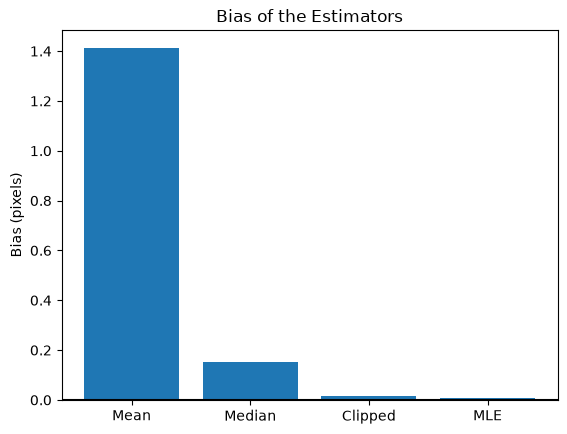

In [52]:
names = ["Mean", "Median", "Clipped", "MLE"]
biases = [meanbias, medbias, clipbias, mlebias]

plt.bar(names, biases)
plt.axhline(0, color="black")
plt.ylabel("Bias (pixels)")
plt.title("Bias of the Estimators")
plt.show()

In [63]:
meanvar = np.var(means)
medvar = np.var(medians)
clipvar = np.var(clips)
mlevar = np.var(mles)

print("Mean variance =", meanvar)
print("Median variance =", medvar)
print("Clipped variance =", clipvar)
print("MLE variance =", mlevar)

Mean variance = 0.09721065034461392
Median variance = 0.013551479698764702
Clipped variance = 0.013111528982151437
MLE variance = 0.009199609887611608


In [54]:
grid = np.linspace(0, 64, 20000)

star = a * (1 + ((grid - truthx) / r0)**2)**(-beta)
p = (1 - truthf)*star + truthf*back

dstar = star * 2*beta*(grid - truthx) / (r0**2 + (grid - truthx)**2)
dx = (1 - truthf)*dstar
df = back - star

i00 = np.trapezoid(dx**2 / p, grid)
i01 = np.trapezoid(dx * df / p, grid)
i11 = np.trapezoid(df**2 / p, grid)

fish = np.array([[i00, i01], [i01, i11]])
fish = len(x) * fish

simcov = np.linalg.inv(fish)
simcr = np.sqrt(simcov[0, 0])
simvar = simcr**2

print("Simulation CRB =", simcr)

Simulation CRB = 0.09550631826994332


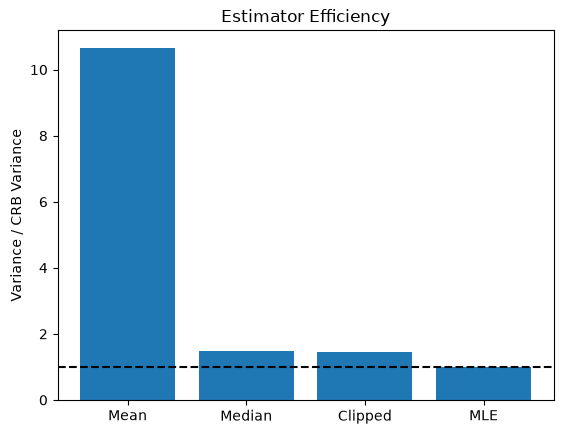

In [55]:
vars = [meanvar, medvar, clipvar, mlevar]
ratios = np.array(vars) / simvar

plt.bar(names, ratios)
plt.axhline(1, color="black", linestyle="--")
plt.ylabel("Variance / CRB Variance")
plt.title("Estimator Efficiency")
plt.show()


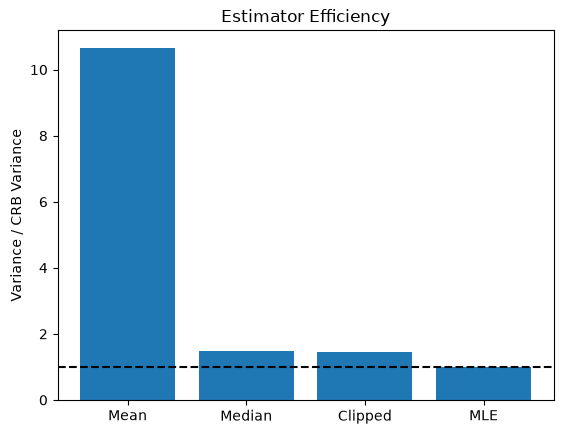

In [56]:
vars = [meanvar, medvar, clipvar, mlevar]
ratios = np.array(vars) / simvar

plt.bar(names, ratios)
plt.axhline(1, color="black", linestyle="--")
plt.ylabel("Variance / CRB Variance")
plt.title("Estimator Efficiency")
plt.show()


In [59]:
meancov = np.mean(np.abs(means - truthx) <= meanerr)
medcov = np.mean(np.abs(medians - truthx) <= mederr)
clipcov = np.mean(np.abs(clips - truthx) <= cliperr)
mlecov = np.mean(np.abs(mles - truthx) <= mlexerr)

print("Mean coverage =", 100*meancov, "%")
print("Median coverage =", 100*medcov, "%")
print("Clipped coverage =", 100*clipcov, "%")
print("MLE coverage =", 100*mlecov, "%")

Mean coverage = 0.0 %
Median coverage = 25.5 %
Clipped coverage = 66.0 %
MLE coverage = 68.0 %


In [60]:
test = mlex + 2*np.random.standard_t(4, 1000000)
lost = (test < 0) | (test > 64)
lostfrac = np.mean(lost)

print("Lost fraction =", lostfrac)
print("Lost percent =", 100*lostfrac, "%")


Lost fraction = 0.000183
Lost percent = 0.0183 %


In [61]:
print("FINAL RESULTS")
print("Mean =", mean, "+/-", meanerr)
print("Median =", median, "+/-", mederr)
print("Clipped =", clip, "+/-", cliperr)
print("MLE x0 =", mlex, "+/-", mlexerr)
print("MLE f =", mlef, "+/-", mleferr)
print("CRB =", cr)
print("Mean bias =", meanbias)
print("Median bias =", medbias)
print("Clipped bias =", clipbias)
print("MLE bias =", mlebias)
print("Mean coverage =", 100*meancov, "%")
print("Median coverage =", 100*medcov, "%")
print("Clipped coverage =", 100*clipcov, "%")
print("MLE coverage =", 100*mlecov, "%")
print("Lost percent =", 100*lostfrac, "%")

FINAL RESULTS
Mean = 25.199322113879003 +/- 0.34590104448922376
Median = 23.592328 +/- 0.09452431656486181
Clipped = 23.488543213872834 +/- 0.11695970093120481
MLE x0 = 23.42 +/- 0.09763284315333925
MLE f = 0.24 +/- 0.017952742154334497
CRB = 0.0989341059795359
Mean bias = 1.4127553106752373
Median bias = 0.15038361842497494
Clipped bias = 0.01435215558750258
MLE bias = 0.008383618425060746
Mean coverage = 0.0 %
Median coverage = 25.5 %
Clipped coverage = 66.0 %
MLE coverage = 68.0 %
Lost percent = 0.0183 %


**WHAT THE CHECKS FOUND:**

*The closure test seems to have worked well. The true star position was 25 pixels, and the MLE recovered 25.05 pixels. The true background fraction was 0.20, and the recovered value was 0.18 so the estimator was close to the known truth.

For bias and efficiency, the regular mean performed the worst and had a large bias of about 1.41 pixels. The median was better but still had some bias. The sigma-clipped mean and MLE had very small biases and the MLE had the smallest bias. The MLE also had the smallest variance and was closest to the Cramér–Rao bound which means it was the most efficient estimator.

For coverage, the mean had 0% coverage and the median had only 25.5%, so their uncertainty estimates did not work well. The sigma-clipped mean had 66% coverage, which was close to the expected 68%. The MLE had exactly 68% coverage, so its uncertainty estimate worked very well.

For sensitivity, only about 0.0183% of simulated photons fell outside the detector window. This is very very small, so lost photons are not important for this dataset. I did not yet test changing (r0) or (beta), so that part of the sensitivity check still needs to be done.*

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

*I used ChatGPT throughout this lab. I used it to help me understand the statistical ideas in the assignment and to write and debug come parts of the Python code. Especially to help write my verification plan code in Part 3b and to interpret the closure, bias, efficiency, coverage, and sensitivity tests. I did not accept everything ChatGPT gave me without checking it. For example, ChatGPT initially described the sensitivity section as if I had tested changes in both (r_0) and (beta), but my actual code only tested the fraction of photons lost outside the detector window.*